In [ ]:
# Q1. 유저정보와 게임 플레이 기록을 바탕으로 2023년 1월부터 12월까지 가입한 고객에 대해, M1, M2, M3,,,, M12의 리텐션율, 이탈율, 전체 플레이타임 시각화
# Q2. 3개월 내 이탈한 고객과 비이탈한 고객의 게임 플레이 패턴에서 어떤 차이가 있는지를 파악하세요

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns # heatmap 그리기 위해

In [3]:
log_df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\game_play_log.csv")
customer_df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\game_customers.csv")

In [73]:
log_df.head() # 하기 Play_time은 '분'

,customer_id,play_date,play_time,play_ym
0,C00001,2023-04-13,37,202304
1,C00001,2023-04-25,63,202304
2,C00001,2023-05-13,14,202305
3,C00001,2023-05-27,6,202305
4,C00002,2023-12-15,35,202312


In [9]:
customer_df.head()

,customer_id,signup_date
0,C00001,2023-04-13
1,C00002,2023-12-15
2,C00003,2023-09-28
3,C00004,2023-04-17
4,C00005,2023-03-13


In [10]:
# 날짜가 있으니 당연히 pd.to_datetime() 활용하여 날짜형으로 변형 (습관)
log_df['play_date'] = pd.to_datetime(log_df['play_date'])
customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'])

In [13]:
# .dt.strftime('%Y%m') 활용하여 YYYYMM 형식으로 바꾸기
log_df['play_ym'] = log_df['play_date'].dt.strftime('%Y%m')
customer_df['signup_ym'] = customer_df['signup_date'].dt.strftime('%Y%m') # String Format Time

In [14]:
log_df['play_ym'].head()

0    202304
1    202304
2    202305
3    202305
4    202312
Name: play_ym, dtype: object

In [18]:
# 가입한 날짜를 기준으로 마지막 play한 날짜와 비교해야하니 우선 가입한 날짜를 리스트화 시키는 작업
signup_ym_list = sorted(customer_df['signup_ym'].unique()) # Unique 함수가 없으면 중복값이 너무 많이 발생
signup_ym_list

['202301',
 '202302',
 '202303',
 '202304',
 '202305',
 '202306',
 '202307',
 '202308',
 '202309',
 '202310',
 '202311',
 '202312']

In [21]:
last_play_ym = log_df.groupby('customer_id')['play_ym'].max()
last_play_ym

customer_id
C00001    202305
C00002    202404
C00003    202406
C00004    202304
C00005    202501
           ...  
C09996    202309
C09997    202401
C09998    202501
C09999    202308
C10000    202501
Name: play_ym, Length: 10000, dtype: object

In [26]:
def add_month(ym,m):   #YYYYMM을 Year와 Month로 구분해주고 Int (숫자형)으로 변형
    year = int(ym[:4]) 
    month = int(ym[4:])

    #월 계산: 12개월이후부터는 다시 Year+1해주고 1월로 돌아가야한다 (*다른 접근법도 가능)
    new_month = month + m
    year += (new_month - 1) // 12 # //12는 12나누고 몫을 계산       #연도증가 계산 e.g. 14개월이면 14 - 1 // 12 이니 Year가 1년 + 된다
    new_month = (new_month - 1) % 12 + 1 # % 12는 12로 나눴을때 나머지를 계산    #월을 1~12 사이로 항상 유지 e.g. 17이면, 16/12+1

    # 결과 반환하는데, 이번에는 Int (숫자형) 에서 Str (글자형) 으로 바꾼다. 숫자면 더해져버리닌깐 문화가 필요하다
    return str(year) + str(new_month).zfill(2)  #zfill(2)는 문자열의 0을 추가해서 열을 맞추주는 메서드 e.g. 20252 > 202502로 변환

In [29]:
print(add_month('202409', 5))
print(add_month('202411', 6))

202502
202505


In [49]:
# 여긴 이해 못했다 (12/30/2025)
# Retention Graph를 그리기 위한 준비
retention_data = []
playtime_data = []
# 두개를 동시에 채울수도 있네.. For 문을 여러개를 따로돌리는것은 비효율적. 최대한 묶어서 한번에 돌려야한다.

# 하기 for 문을 보면 2개가 있는데, 보통 첫번째(or 바깥쪽) For문은 행을, 두번째 (or 안쪽) For문은 열을 만든다
for i in range(12): # 가입년월이 Unique값으로 12개
    ym = signup_ym_list[i]
    ym_signup_users = customer_df.loc[customer_df['signup_ym'] == ym, 'customer_id'].tolist() #,tolist()는 리스트로 바꾸는 명령어
    last_play_ym_ym = last_play_ym.loc[ym_signup_users] # 위 코드에 들어간 ym_signup_users 고객들을 대상으로 Last Play 확인   
    retention_record = []
    playtime_record = []
    for j in range(1,13): # '월'을 순회하면서 1월 (=1) ~ 12월 (=13)까지
        ym_j = add_month(ym, j)
        retention = sum(last_play_ym_ym >= ym_j) / len(ym_signup_users) * 100  # 분모는 전체 즉 Cohort의 전체명수; 분자는 가장늦게플레이 > ym_j
        retention_record.append(retention) # J월 후까지 남아있는 유저의 수

        play_log = log_df.loc[(log_df['customer_id'].isin(ym_signup_users)) & (log_df['play_ym'] == ym_j)] # 전체 Cohort 안에 있고 & j월에 play이력 
        total_play_time = play_log['play_time'].sum()
        playtime_record.append(total_play_time)

    retention_data.append(retention_record)
    playtime_data.append(playtime_record)

In [50]:
retention_data # 보기너무 불편하니 dataframe형태로 변환

[[96.27473806752037,
  89.28987194412107,
  80.44237485448195,
  72.75902211874272,
  64.0279394644936,
  56.57741559953434,
  49.47613504074505,
  42.0256111757858,
  34.458672875436555,
  29.918509895227007,
  29.918509895227007,
  29.918509895227007],
 [97.23320158102767,
  89.19631093544137,
  82.08168642951252,
  72.85902503293808,
  64.95388669301713,
  56.126482213438734,
  47.43083003952569,
  39.52569169960474,
  30.698287220026348,
  28.063241106719367,
  28.063241106719367,
  28.063241106719367],
 [95.02427184466019,
  86.77184466019418,
  79.00485436893204,
  71.11650485436894,
  63.3495145631068,
  54.97572815533981,
  47.69417475728155,
  40.04854368932039,
  32.16019417475729,
  28.276699029126213,
  28.276699029126213,
  28.276699029126213],
 [95.49132947976878,
  87.39884393063583,
  80.0,
  73.29479768786126,
  65.54913294797687,
  59.42196531791908,
  49.2485549132948,
  41.61849710982659,
  34.21965317919075,
  30.057803468208093,
  30.057803468208093,
  30.05780346

In [52]:
retention_data = pd.DataFrame(retention_data, 
                              index = signup_ym_list, # 행을 나타낸다 (첫뻔째 For문)
                              columns = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']) # 열을 나타낸다 (두번째 For문)

In [53]:
retention_data
# 아래데이터를 해석하면, 202301 가입한 사람중에 M1에도 Play한 비율이 96%, M12는 29%밖에 안된다.
# 그럼 여기서 왜 202305년도 Cohort는 Retention 률이 높은지 추가분석도 가능하다

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
202301,96.274738,89.289872,80.442375,72.759022,64.027939,56.577416,49.476135,42.025611,34.458673,29.918510,29.918510,29.918510
202302,97.233202,89.196311,82.081686,72.859025,64.953887,56.126482,47.430830,39.525692,30.698287,28.063241,28.063241,28.063241
202303,95.024272,86.771845,79.004854,71.116505,63.349515,54.975728,47.694175,40.048544,32.160194,28.276699,28.276699,28.276699
202304,95.491329,87.398844,80.000000,73.294798,65.549133,59.421965,49.248555,41.618497,34.219653,30.057803,30.057803,30.057803
202305,96.296296,92.013889,83.217593,76.157407,68.055556,60.416667,53.587963,44.560185,36.226852,31.944444,31.944444,31.944444
202306,95.362663,87.277051,80.380499,72.413793,64.684899,57.312723,48.275862,41.141498,34.007134,30.677765,30.677765,30.677765
202307,96.181384,88.186158,80.071599,72.076372,63.484487,57.040573,49.522673,42.482100,33.412888,30.429594,30.429594,30.429594
202308,95.099183,87.397900,81.796966,73.745624,64.177363,56.476079,49.941657,40.140023,31.971995,28.704784,28.704784,28.704784
202309,96.143959,87.789203,79.305913,70.437018,62.082262,55.655527,47.043702,39.717224,32.390746,29.177378,29.177378,29.177378
202310,95.698925,86.738351,77.658303,69.772999,62.724014,55.675030,48.506571,39.784946,32.258065,29.032258,29.032258,29.032258


<Axes: >

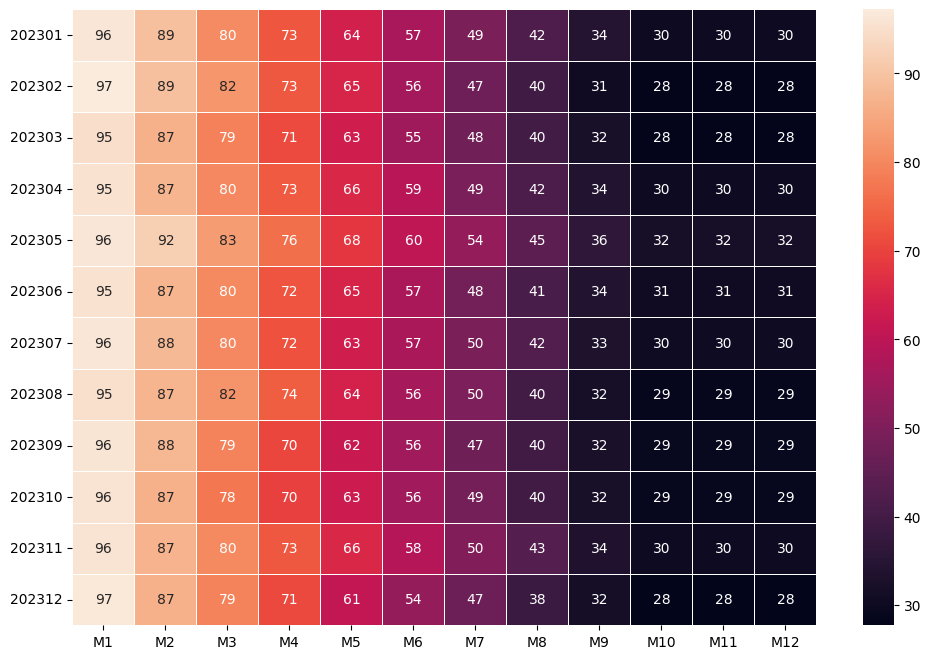

In [56]:
# 그래프를 그릴거다
plt.figure(figsize = (12,8))
sns.heatmap(retention_data, linewidth = 0.5, annot = True, fmt = '.0f')

In [59]:
# Retention이 나왔으니 이탈 (Churn)은 당연히 100 - Retentiona
churn_data = 100 - retention_data
churn_data

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
202301,3.725262,10.710128,19.557625,27.240978,35.972061,43.422584,50.523865,57.974389,65.541327,70.081490,70.081490,70.081490
202302,2.766798,10.803689,17.918314,27.140975,35.046113,43.873518,52.569170,60.474308,69.301713,71.936759,71.936759,71.936759
202303,4.975728,13.228155,20.995146,28.883495,36.650485,45.024272,52.305825,59.951456,67.839806,71.723301,71.723301,71.723301
202304,4.508671,12.601156,20.000000,26.705202,34.450867,40.578035,50.751445,58.381503,65.780347,69.942197,69.942197,69.942197
202305,3.703704,7.986111,16.782407,23.842593,31.944444,39.583333,46.412037,55.439815,63.773148,68.055556,68.055556,68.055556
202306,4.637337,12.722949,19.619501,27.586207,35.315101,42.687277,51.724138,58.858502,65.992866,69.322235,69.322235,69.322235
202307,3.818616,11.813842,19.928401,27.923628,36.515513,42.959427,50.477327,57.517900,66.587112,69.570406,69.570406,69.570406
202308,4.900817,12.602100,18.203034,26.254376,35.822637,43.523921,50.058343,59.859977,68.028005,71.295216,71.295216,71.295216
202309,3.856041,12.210797,20.694087,29.562982,37.917738,44.344473,52.956298,60.282776,67.609254,70.822622,70.822622,70.822622
202310,4.301075,13.261649,22.341697,30.227001,37.275986,44.324970,51.493429,60.215054,67.741935,70.967742,70.967742,70.967742


<Axes: >

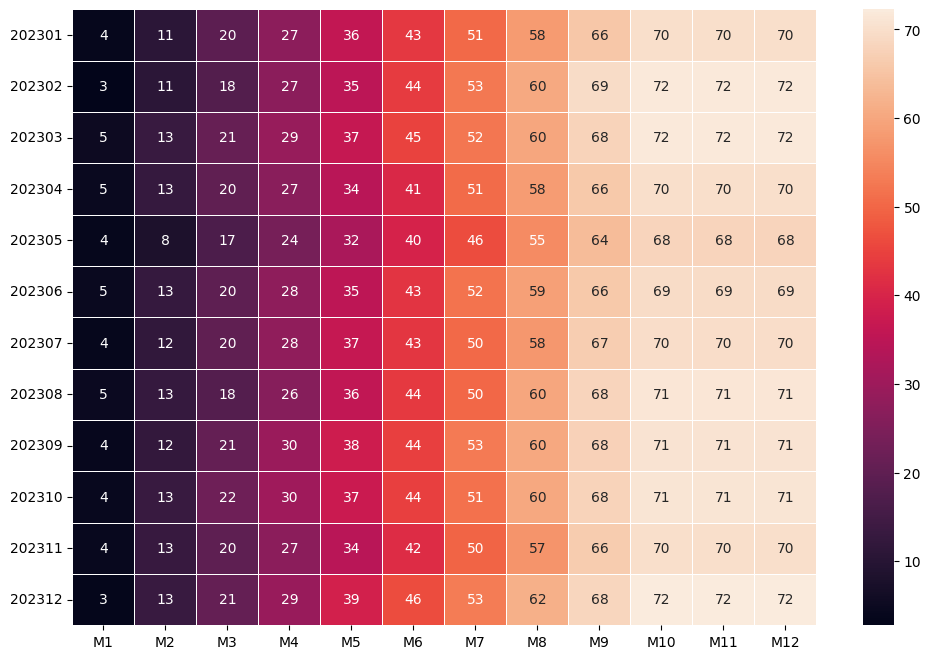

In [60]:
plt.figure(figsize = (12,8))
sns.heatmap(churn_data, linewidth = 0.5, annot = True, fmt = '.0f')

<Axes: >

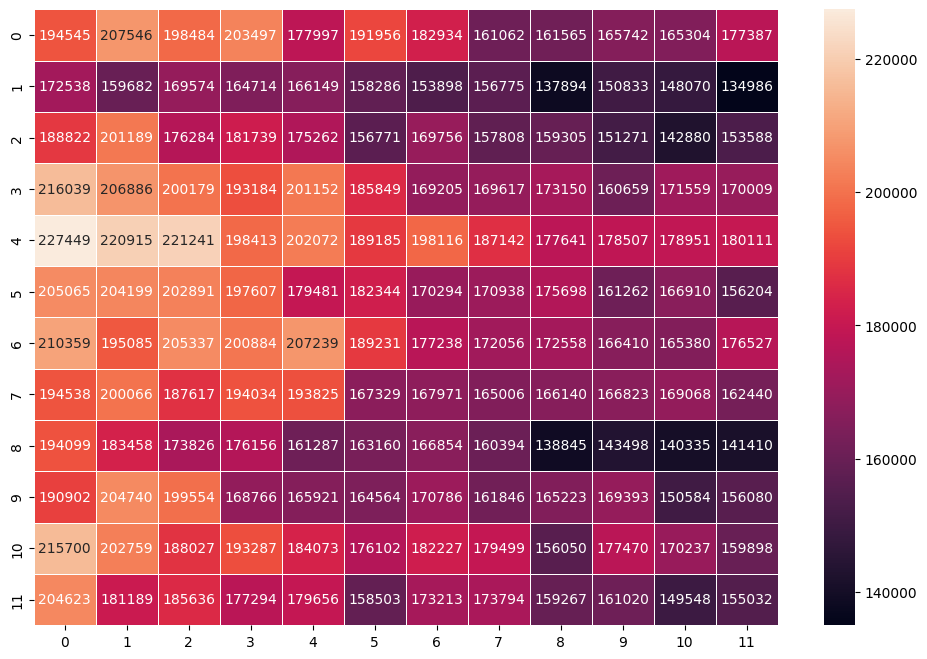

In [61]:
#Playtime 분단위로 보여줌 (Heatmap은 숫자가 크면 가독성이 낮다)
plt.figure(figsize = (12,8))
sns.heatmap(playtime_data, linewidth = 0.5, annot = True, fmt = '.0f')

<Axes: >

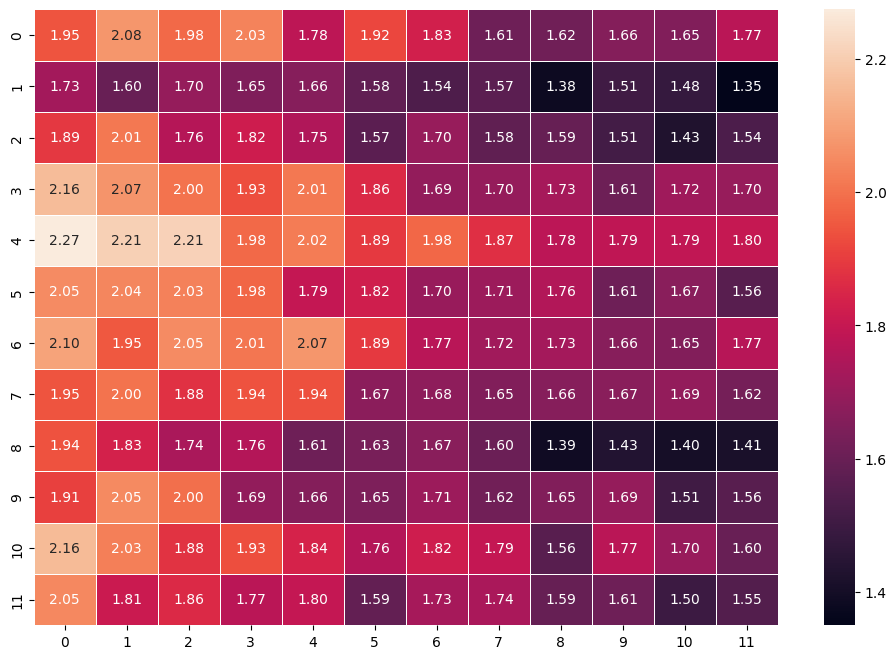

In [71]:
#보기좋게 백만(1e6), 천(1e3) 단위로 변경 ** 1 x 1의 6승 - 백만 이라는 의미
import numpy as np
plt.figure(figsize = (12,8))
playtime_data = np.array(playtime_data) # Np로 바꿔주기 전에는 형식으로 인한 Error발생
sns.heatmap(playtime_data / 1e5, linewidth = 0.5, annot = True, fmt = '.2f')

In [82]:
customer_df = customer_df.merge(last_play_ym, left_on = 'customer_id', right_index = True)
# Right_index = True: last_play_ym이 형식이 없는 시리즈이니, Index (Customer_id를 기준으로 붙인가는 의미
# 위를 하기싶다면, last_play_ym.reset_index()를 써서, index화 시키고, merge(last_play_ym, left_on = 'customer_id', on) 으로 할수도 있다
# or pd.merge(customer_df, last_play_ym)
customer_df.head()

,customer_id,signup_date,signup_ym,play_ym_x,play_ym_y,play_ym
0,C00001,2023-04-13,202304,202305,202305,202305
1,C00002,2023-12-15,202312,202404,202404,202404
2,C00003,2023-09-28,202309,202406,202406,202406
3,C00004,2023-04-17,202304,202304,202304,202304
4,C00005,2023-03-13,202303,202501,202501,202501


In [83]:
# 왜 위에 중복값이 나왔는지 모르겠으나, play로 시작하는 3개 칼럼 데이터가 동일. 마지막 play = signup_ym으로 차이 찾아야한다.
# 저 숫자를 그냥빼면, 월이라서 이슈생긴다
def minus_ym(row):
    ym1 = row['signup_ym']
    ym2 = row['play_ym']

    year1 = int(ym1[:4])
    month1 = int(ym1[4:])

    year2 = int(ym2[:4])
    month2 = int(ym2[4:])

    output = (year2 * 12 + month2) - (year1 *12 + month1)
    return output

In [87]:
customer_df['play_duration'] = customer_df[['signup_ym', 'play_ym']].apply(minus_ym, axis = 1)
customer_df['churn'] = customer_df['play_duration'] <=3
customer_df.head()

,customer_id,signup_date,signup_ym,play_ym_x,play_ym_y,play_ym,play_duration,churn
0,C00001,2023-04-13,202304,202305,202305,202305,1,True
1,C00002,2023-12-15,202312,202404,202404,202404,4,False
2,C00003,2023-09-28,202309,202406,202406,202406,9,False
3,C00004,2023-04-17,202304,202304,202304,202304,0,True
4,C00005,2023-03-13,202303,202501,202501,202501,22,False


In [91]:
churn_log = log_df.loc[log_df['customer_id'].isin(customer_df.loc[customer_df['churn'], 'customer_id'])]
not_churn_log = log_df.loc[~log_df['customer_id'].isin(customer_df.loc[customer_df['churn'], 'customer_id'])]

Text(0, 0.5, 'avg monthly playtime (unit: minute)')

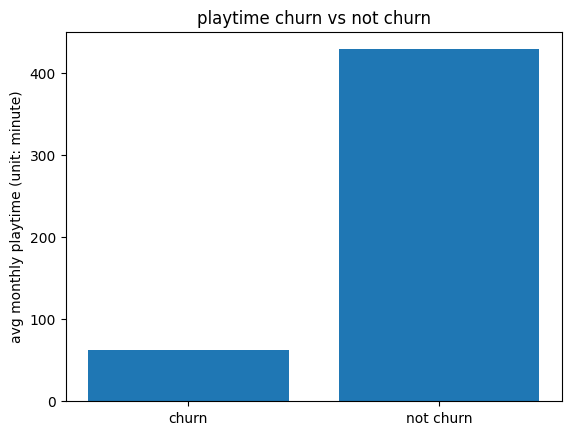

In [96]:
plt.title('playtime churn vs not churn')
plt.bar(['churn', 'not churn'],
        [churn_log.groupby(['customer_id', 'play_ym'])['play_time'].sum().mean(), not_churn_log.groupby(['customer_id', 'play_ym'])['play_time'].sum().mean()])

plt.ylabel('avg monthly playtime (unit: minute)')